<h1>Case Técnico — Ciência de Dados</h1>

<h2>Sistema de Recomendação de Produtos Financeiros II</h2>

<h3>Por Beatriz Ottoboni</h3>

<b><h2>Sumário</h2></b>
<h4><a href='#eda'>1. Exploratory Data Analysis (EDA)</a></h4>
<h4><a href='#tratamento'>2. Tratamento de Dados e Feature Engineering</a></h4>
<h4><a href='#modelagem'>3. Modelagem</a></h4>
<h4><a href='#avaliacao'>4. Avaliação</a></h4>
<h4><a href='#conclusao'>5. Conclusão</a></h4>

<a id='eda'></a><h3>1. Exploratory Data Analysis (EDA)

Bibliotecas e requirements

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE

import tensorflow as tf
import keras
from keras import ops
from keras import layers

pd.set_option('display.max_columns', 500)

In [2]:
# import matplotlib
# matplotlib.__version__

In [3]:
# Garantir reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

os.environ['PYTHONHASHSEED']       = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'


versoes bibliotecas<br>
pandas==2.2.2
numpy==2.0.2
matplotlib==3.10.0
seaborn==0.13.2


funções

In [66]:
class RecsysAutoencoder(tf.keras.Model):
    def __init__(self, n_produtos, n_clientes_features, latent_dim=16):
        super().__init__()
        input_dim = n_produtos + n_clientes_features

        init = tf.keras.initializers.GlorotUniform(seed=SEED)

        self.encoder = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(input_dim,)),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),
            tf.keras.layers.Dense(64, kernel_initializer=init),
            tf.keras.layers.Dense(32, activation='relu', kernel_initializer=init),
            tf.keras.layers.Dense(latent_dim, kernel_initializer=init)
        ])

        self.decoder = tf.keras.Sequential([
            tf.keras.layers.Dense(32, activation='relu', kernel_initializer=init),
            tf.keras.layers.Dense(64, activation='relu', kernel_initializer=init),
            tf.keras.layers.Dense(n_produtos, kernel_initializer=init)
        ])

    def call(self, x, training=False):
        z = self.encoder(x, training=training)
        logits = self.decoder(z, training=training)
        probs = tf.nn.softmax(logits, axis=1)
        return probs, z

def weighted_loss(probs, targets, margens):
    epsilon = 1e-8
    bce = -(targets * tf.math.log(probs + epsilon) +
            (1 - targets) * tf.math.log(1 - probs + epsilon))
    peso = margens / tf.reduce_sum(margens)
    loss = tf.reduce_mean(tf.reduce_sum(bce * peso, axis=1))
    return loss


In [67]:
def cartesiano(df_1, df_2):
    df_1['key'] = 1
    df_2['key'] = 1
    df_cart = df_1.merge(df_2, on='key').drop('key', axis=1)
    return df_cart

Leitura datsets

In [6]:
clientes = pd.read_csv('https://raw.githubusercontent.com/iamsamucoding/case-sistema-recomendacao-II/refs/heads/main/data/clientes.csv', sep=',')
contratos_ativos = pd.read_csv('https://raw.githubusercontent.com/iamsamucoding/case-sistema-recomendacao-II/refs/heads/main/data/contratos_ativos.csv', sep=',')
interacoes = pd.read_csv('https://raw.githubusercontent.com/iamsamucoding/case-sistema-recomendacao-II/refs/heads/main/data/interacoes.csv', sep=',')
produtos = pd.read_csv('https://raw.githubusercontent.com/iamsamucoding/case-sistema-recomendacao-II/refs/heads/main/data/produtos.csv', sep=',')

1.1. Dataset Clientes

In [7]:
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_cliente                   50000 non-null  int64  
 1   idade                        50000 non-null  int64  
 2   genero                       50000 non-null  object 
 3   uf                           50000 non-null  object 
 4   segmento                     50000 non-null  object 
 5   score_credito                48448 non-null  float64
 6   renda_mensal                 48499 non-null  float64
 7   saldo_medio_conta            50000 non-null  float64
 8   qtd_meses_cliente            50000 non-null  int64  
 9   qtd_produtos_ativos          50000 non-null  int64  
 10  qtd_transacoes_pix_6m        50000 non-null  int64  
 11  vlr_total_investimentos      48561 non-null  float64
 12  vlr_medio_gasto_cartao       50000 non-null  float64
 13  vlr_medio_gasto_

In [8]:
clientes.head()

,id_cliente,idade,genero,uf,segmento,score_credito,renda_mensal,saldo_medio_conta,qtd_meses_cliente,qtd_produtos_ativos,qtd_transacoes_pix_6m,vlr_total_investimentos,vlr_medio_gasto_cartao,vlr_medio_gasto_alimentacao,vlr_medio_gasto_transporte,vlr_medio_gasto_saude,vlr_medio_gasto_educacao,vlr_medio_gasto_lazer,ind_debito_automatico,qtd_dias_inatividade,vlr_limite_credito,pct_utilizacao_limite,canal_preferencial
0,1,34,F,PR,basico,617.21,1500.00,2981.16,17,0,2,NaN,626.54,97.96,139.06,38.89,35.88,114.53,1,12.0,725.95,0.2062,agencia
1,2,58,F,SP,premium,700.98,16620.77,41901.11,21,8,36,120463.82,3908.82,705.43,679.74,487.83,147.66,415.77,0,6.0,14116.66,0.1795,web
2,3,46,F,AM,intermediario,696.96,4202.55,916.78,57,2,5,0.00,2233.98,795.14,239.72,69.56,245.75,357.10,1,8.0,4414.47,0.4499,app
3,4,31,M,RS,intermediario,611.78,5969.66,10472.53,58,0,8,2741.29,2777.27,704.23,582.83,182.11,21.38,520.29,0,3.0,4992.60,0.3728,app
4,5,56,F,MG,basico,233.49,1816.86,1909.79,32,0,3,2996.98,204.49,49.23,36.48,26.78,9.68,19.63,0,0.0,2139.83,0.5960,app


In [9]:
clientes.describe()

,id_cliente,idade,score_credito,renda_mensal,saldo_medio_conta,qtd_meses_cliente,qtd_produtos_ativos,qtd_transacoes_pix_6m,vlr_total_investimentos,vlr_medio_gasto_cartao,vlr_medio_gasto_alimentacao,vlr_medio_gasto_transporte,vlr_medio_gasto_saude,vlr_medio_gasto_educacao,vlr_medio_gasto_lazer,ind_debito_automatico,qtd_dias_inatividade,vlr_limite_credito,pct_utilizacao_limite
count,50000.000000,50000.000000,48448.000000,48499.000000,50000.000000,50000.000000,50000.000000,50000.000000,4.856100e+04,50000.000000,50000.000000,50000.000000,48492.000000,48547.000000,48479.000000,50000.000000,48472.000000,50000.000000,50000.000000
mean,25000.500000,38.276660,543.917928,4939.488462,7600.531757,37.756680,2.009380,9.891420,1.227417e+04,1969.868022,542.012247,296.127395,167.444915,117.366687,226.313176,0.350540,11.846633,5103.564543,0.341504
std,14433.901067,11.351267,178.095975,4081.044502,8129.777578,45.108484,1.748346,8.719215,3.819689e+04,1947.935145,575.018453,335.227759,196.116441,149.154678,262.964865,0.477144,19.995771,5689.679388,0.168044
min,1.000000,18.000000,50.000000,1500.000000,150.500000,1.000000,0.000000,0.000000,0.000000e+00,150.920000,23.990000,8.590000,3.340000,0.000000,5.290000,0.000000,0.000000,500.000000,0.001900
25%,12500.750000,30.000000,419.060000,2297.575000,2611.697500,9.000000,1.000000,4.000000,0.000000e+00,782.500000,199.197500,99.567500,53.290000,30.070000,72.850000,0.000000,2.000000,1684.227500,0.214700
50%,25000.500000,38.000000,542.850000,3617.500000,5072.695000,23.000000,2.000000,7.000000,4.472000e+02,1359.305000,362.520000,189.900000,105.415000,70.160000,142.780000,0.000000,5.000000,3077.955000,0.321900
75%,37500.250000,46.000000,675.692500,6218.080000,9597.317500,49.000000,3.000000,13.000000,8.067660e+03,2447.735000,669.737500,364.700000,204.922500,145.165000,279.725000,1.000000,12.000000,6101.360000,0.451100
max,50000.000000,80.000000,1000.000000,56042.480000,141333.440000,480.000000,13.000000,116.000000,1.588884e+06,31389.140000,10216.520000,6027.210000,3547.970000,2825.510000,4888.040000,1.000000,278.000000,72275.690000,1.000000


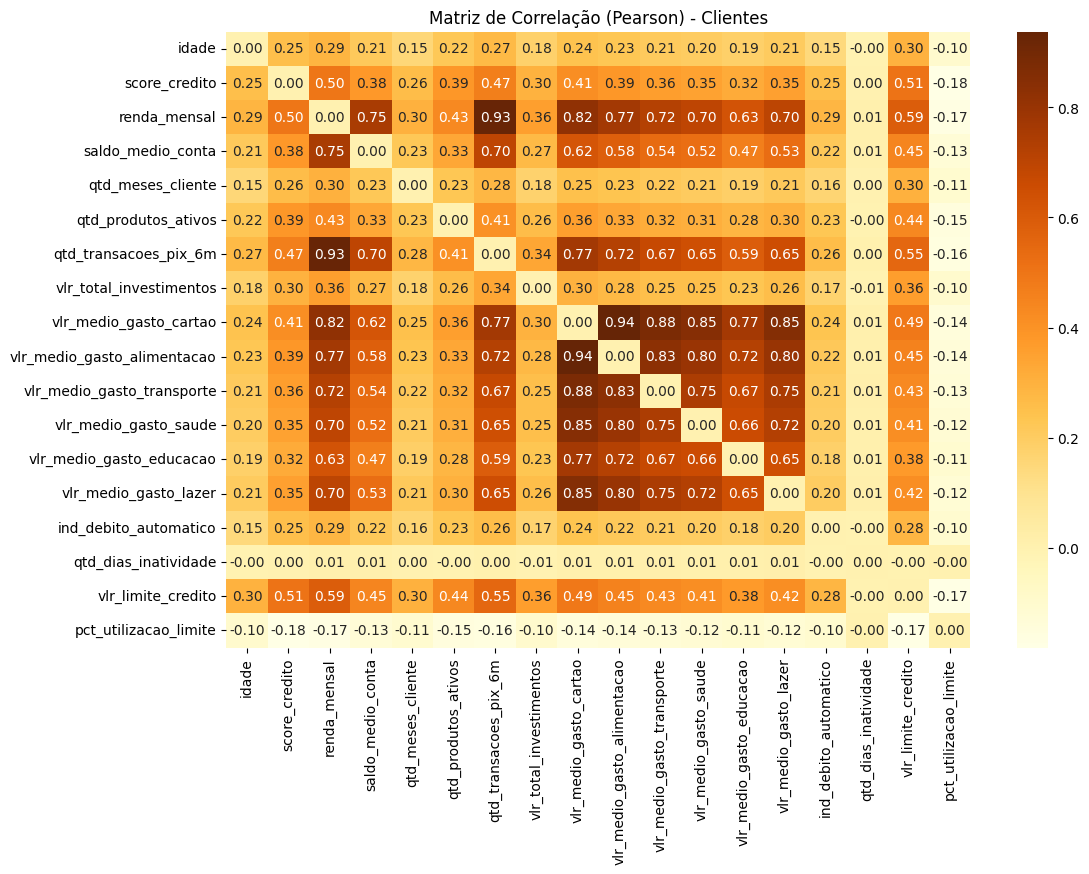

In [10]:
vars_num = ['idade', 'score_credito',
       'renda_mensal', 'saldo_medio_conta', 'qtd_meses_cliente',
       'qtd_produtos_ativos', 'qtd_transacoes_pix_6m',
       'vlr_total_investimentos', 'vlr_medio_gasto_cartao',
       'vlr_medio_gasto_alimentacao', 'vlr_medio_gasto_transporte',
       'vlr_medio_gasto_saude', 'vlr_medio_gasto_educacao',
       'vlr_medio_gasto_lazer', 'ind_debito_automatico',
       'qtd_dias_inatividade', 'vlr_limite_credito', 'pct_utilizacao_limite']

corr_matrix = clientes[vars_num].corr()
corr_matrix_zero = corr_matrix.mask(np.eye(len(corr_matrix), dtype=bool), 0)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix_zero, annot=True, cmap='YlOrBr', fmt=".2f")
plt.title("Matriz de Correlação (Pearson) - Clientes")
plt.show()

1.2. Dataset produtos

In [11]:
produtos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   produto          20 non-null     object 
 1   categoria        20 non-null     object 
 2   receita_media    20 non-null     float64
 3   custo_aquisicao  20 non-null     float64
 4   margem           20 non-null     float64
 5   publico_alvo     20 non-null     object 
dtypes: float64(3), object(3)
memory usage: 1.1+ KB


In [12]:
display(produtos.sort_values(by='margem', ascending=False))

,produto,categoria,receita_media,custo_aquisicao,margem,publico_alvo
10,tesouro_direto,investimento,70.0,8.0,0.89,Clientes que buscam investimento seguro com li...
7,investimento_cdb,investimento,95.0,10.0,0.89,Clientes com capital disponivel para investime...
16,consorcio_imovel,consorcio,450.0,55.0,0.88,Clientes que desejam adquirir imovel de forma ...
8,investimento_lci_lca,investimento,110.0,14.0,0.87,Clientes com perfil investidor que buscam isen...
9,previdencia,investimento,150.0,20.0,0.87,Clientes com visao de longo prazo e capacidade...
4,cheque_especial,credito,90.0,12.0,0.87,Clientes que precisam de credito emergencial d...
11,seguro_vida,seguro,85.0,12.0,0.86,"Clientes com dependentes, preocupados com prot..."
5,uso_lastro_limite,credito,35.0,5.0,0.86,Clientes com investimentos que desejam aumenta...
15,consorcio_auto,consorcio,320.0,45.0,0.86,Clientes que desejam adquirir veiculo de forma...
19,portabilidade_salario,conta,20.0,3.0,0.85,Clientes com conta salario em outro banco


1.3. Dataset contratos_ativos

In [13]:
contratos_ativos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61997 entries, 0 to 61996
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id_cliente         61997 non-null  int64 
 1   produto            61997 non-null  object
 2   data_contratacao   61997 non-null  object
 3   status             61997 non-null  object
 4   canal_contratacao  61997 non-null  object
dtypes: int64(1), object(4)
memory usage: 2.4+ MB


In [14]:
contratos_ativos.head()

,id_cliente,produto,data_contratacao,status,canal_contratacao
0,1,previdencia,2025-10-23,ativo,app
1,4,seguro_residencial,2025-10-26,cancelado,app
2,4,conta_digital_plus,2025-03-25,ativo,app
3,5,credito_consignado,2024-08-08,ativo,agencia
4,5,cheque_especial,2025-09-04,ativo,app


In [15]:
contratos_ativos['status'].unique()

array(['ativo', 'cancelado', 'vencido'], dtype=object)

In [16]:
contratos_ativos['canal_contratacao'].unique()

array(['app', 'agencia', 'web', 'telemarketing'], dtype=object)

In [17]:
temp = (contratos_ativos[contratos_ativos['status']=='ativo']
  .groupby('produto')
  .size()
  .rename('proporcao_contratos')
  .sort_values(ascending=False))
temp = round(temp.div(temp.sum(), axis=0),3) * 100
display(temp)

,proporcao_contratos
produto,
conta_digital_plus,15.8
credito_pessoal,15.0
cartao_platinum,9.2
cheque_especial,9.0
pix_parcelado,6.8
seguro_vida,6.5
investimento_cdb,6.5
seguro_auto,5.4
previdencia,5.1


In [18]:
temp = (contratos_ativos[contratos_ativos['status']=='ativo']
  .groupby(['produto', 'canal_contratacao'])
  .size()
  .unstack(fill_value=0))
temp = round(temp.div(temp.sum(axis=1), axis=0),3) * 100
display(temp)

canal_contratacao,agencia,app,telemarketing,web
produto,,,,
cartao_black,17.5,46.5,8.0,28.0
cartao_platinum,19.6,44.9,9.9,25.5
cheque_especial,19.1,45.6,10.3,25.1
consorcio_auto,19.3,44.7,8.9,27.1
consorcio_imovel,20.7,46.5,8.7,24.0
conta_digital_plus,20.3,45.0,9.8,24.9
credito_consignado,21.0,46.6,8.1,24.2
credito_pessoal,20.7,45.5,10.2,23.7
investimento_cdb,19.9,45.9,9.2,24.9


1.4. Dataset interacoes

In [19]:
interacoes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503292 entries, 0 to 503291
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id_interacao      503292 non-null  int64  
 1   id_cliente        503292 non-null  int64  
 2   produto           503292 non-null  object 
 3   posicao_exibicao  503292 non-null  int64  
 4   canal             503292 non-null  object 
 5   clicou            503292 non-null  int64  
 6   contratou         503292 non-null  int64  
 7   receita_gerada    503292 non-null  float64
 8   timestamp         503292 non-null  object 
 9   safra             503292 non-null  int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 38.4+ MB


In [20]:
interacoes.head()

,id_interacao,id_cliente,produto,posicao_exibicao,canal,clicou,contratou,receita_gerada,timestamp,safra
0,1,45719,previdencia,1,push_notification,0,0,0.0,2024-01-22 20:36:00,202401
1,2,46225,conta_digital_plus,1,app_home,0,0,0.0,2024-01-24 14:49:00,202401
2,3,38294,cartao_platinum,5,app_home,0,0,0.0,2024-01-13 10:48:00,202401
3,4,23592,investimento_lci_lca,16,email,0,0,0.0,2024-01-14 14:42:00,202401
4,5,24185,credito_pessoal,17,app_home,0,0,0.0,2024-01-15 11:00:00,202401


In [21]:
temp = (interacoes
    .groupby('produto')
    .agg({'posicao_exibicao':['mean', 'median'],
          'clicou':['sum', 'mean'],
          'contratou':['sum', 'mean'],
          'receita_gerada':'sum'})
    .reset_index())
temp.columns = ['produto', 'posicao_exibicao_mean', 'posicao_exibicao_median', 'clicou_sum', 'clicou_mean', 'contratou_sum', 'contratou_mean', 'receita_gerada']
temp.sort_values(by='receita_gerada', ascending=False)

,produto,posicao_exibicao_mean,posicao_exibicao_median,clicou_sum,clicou_mean,contratou_sum,contratou_mean,receita_gerada
7,credito_pessoal,6.294594,4.0,11234,0.159470,1261,0.017900,282755.29
5,conta_digital_plus,6.311821,4.0,11381,0.160545,1282,0.018084,40384.18
2,cheque_especial,6.238523,4.0,4213,0.094303,347,0.007767,33604.29
13,seguro_auto,6.314010,4.0,2263,0.097317,211,0.009074,29058.48
12,previdencia,6.317784,4.0,1704,0.075272,169,0.007465,27299.60
1,cartao_platinum,6.328932,4.0,5053,0.141059,518,0.014460,24397.85
8,investimento_cdb,6.338402,4.0,2212,0.076625,177,0.006131,17611.93
3,consorcio_auto,6.334793,4.0,991,0.044279,37,0.001653,12024.54
16,seguro_vida,6.330786,4.0,1869,0.062925,89,0.002996,7961.68
14,seguro_residencial,6.298354,4.0,1086,0.072681,116,0.007763,6740.70


In [22]:
temp = (interacoes
    .groupby('canal')
    .agg({'clicou':['sum', 'mean'],
          'contratou':['sum', 'mean'],
          'receita_gerada':'sum'})
    .reset_index())
temp.columns = ['canal', 'clicou_sum', 'clicou_mean', 'contratou_sum', 'contratou_mean', 'receita_gerada']
temp.sort_values(by='receita_gerada', ascending=False)

,canal,clicou_sum,clicou_mean,contratou_sum,contratou_mean,receita_gerada
0,app_busca,16758,0.221996,3244,0.042974,365027.69
1,app_home,18428,0.091339,827,0.004099,87444.78
3,push_notification,4589,0.036549,141,0.001123,16772.27
4,web_banking,3280,0.081822,146,0.003642,16656.14
2,email,3974,0.065789,161,0.002665,16137.56


In [23]:
interacoes_produto = interacoes.copy()
interacoes_produto['data'] = pd.to_datetime(interacoes_produto['timestamp'].str[:10])
interacoes_produto = (interacoes_produto
  .groupby(['data', 'produto', 'canal'])
  .agg({'clicou':'sum', 'contratou':'sum', 'receita_gerada':'sum'})
  .reset_index())

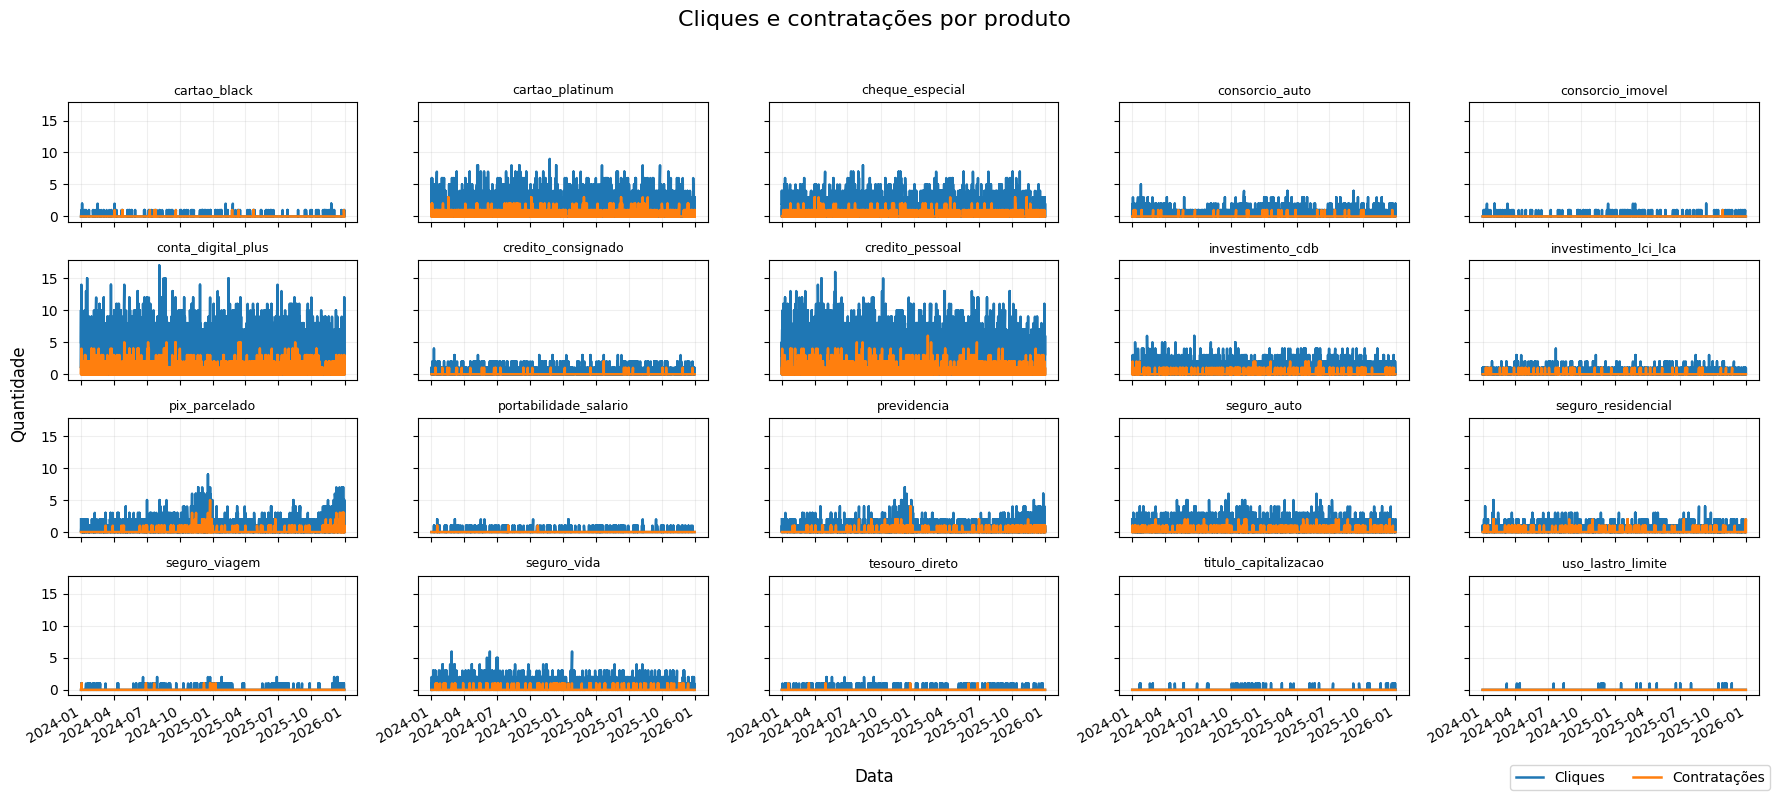

In [24]:
fig, axes = plt.subplots(nrows=4,ncols=5,
    figsize=(18, 8), sharex=True, sharey=True)
axes = axes.flatten()
for ax, produto in zip(axes, interacoes_produto['produto'].unique()):
    d = interacoes_produto[interacoes_produto["produto"] == produto].sort_values("data")

    ax.plot(d["data"], d["clicou"], label="Cliques", linewidth=1.8)
    ax.plot(d["data"], d["contratou"], label="Contratações", linewidth=1.8)

    ax.set_title(produto, fontsize=9)
    ax.grid(True, alpha=0.2)

for ax in axes[len(produtos):]:
    ax.remove()

fig.suptitle("Cliques e contratações por produto", fontsize=16)
fig.supxlabel("Data")
fig.supylabel("Quantidade")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", ncol=2)
fig.autofmt_xdate()
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

<a id='tratamento'></a><h3>2. Tratamento de Dados e Feature Engineering

observações sobre os dados:
- vai ter que ter algum tipo de normalização -> melhor usar standard
- tratamento de missing values

pontos importantes para a modelagem:
existe relação entre número de clientes e contratação?
se existir, considerar não só a contratação mas o número de cliques
para a função de perda: considerar número de clique e produto mais provável -> precisa dar peso para produtos com maior geração de receita e margem
falar sobre inferencia -> captura padrões infere sobre novos


In [25]:
clientes

,id_cliente,idade,genero,uf,segmento,score_credito,renda_mensal,saldo_medio_conta,qtd_meses_cliente,qtd_produtos_ativos,qtd_transacoes_pix_6m,vlr_total_investimentos,vlr_medio_gasto_cartao,vlr_medio_gasto_alimentacao,vlr_medio_gasto_transporte,vlr_medio_gasto_saude,vlr_medio_gasto_educacao,vlr_medio_gasto_lazer,ind_debito_automatico,qtd_dias_inatividade,vlr_limite_credito,pct_utilizacao_limite,canal_preferencial
0,1,34,F,PR,basico,617.21,1500.00,2981.16,17,0,2,NaN,626.54,97.96,139.06,38.89,35.88,114.53,1,12.0,725.95,0.2062,agencia
1,2,58,F,SP,premium,700.98,16620.77,41901.11,21,8,36,120463.82,3908.82,705.43,679.74,487.83,147.66,415.77,0,6.0,14116.66,0.1795,web
2,3,46,F,AM,intermediario,696.96,4202.55,916.78,57,2,5,0.00,2233.98,795.14,239.72,69.56,245.75,357.10,1,8.0,4414.47,0.4499,app
3,4,31,M,RS,intermediario,611.78,5969.66,10472.53,58,0,8,2741.29,2777.27,704.23,582.83,182.11,21.38,520.29,0,3.0,4992.60,0.3728,app
4,5,56,F,MG,basico,233.49,1816.86,1909.79,32,0,3,2996.98,204.49,49.23,36.48,26.78,9.68,19.63,0,0.0,2139.83,0.5960,app
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,30,M,DF,intermediario,816.97,7364.25,4933.59,6,3,11,9063.93,798.23,128.81,170.70,72.74,59.62,43.48,1,2.0,2089.87,0.4360,app
49996,49997,52,M,PR,basico,456.70,3006.73,5952.74,9,3,6,0.00,2049.04,814.20,504.39,261.35,183.10,313.04,0,40.0,2042.59,0.3624,app
49997,49998,51,M,BA,intermediario,795.83,5469.39,15743.30,34,3,10,NaN,1281.96,298.54,274.52,33.77,141.91,64.55,0,1.0,11123.97,0.3083,app
49998,49999,32,M,GO,basico,615.26,2163.89,2132.55,24,1,8,2715.79,1443.35,279.83,301.27,178.10,50.05,78.53,0,7.0,3415.45,0.1559,app


In [26]:
features = ['score_credito', 'renda_mensal', 'saldo_medio_conta', 'qtd_produtos_ativos', 'vlr_medio_gasto_cartao', 'qtd_dias_inatividade', 'vlr_limite_credito']

clientes_train = clientes[['id_cliente'] + features]
clientes_train = clientes_train.set_index('id_cliente')
display(clientes_train.shape)

(50000, 7)

Tratamento de vazios

In [27]:
imputer = SimpleImputer(strategy='median')
imputer.fit(clientes_train)
clientes_train = pd.DataFrame(imputer.transform(clientes_train), index=clientes_train.index, columns=clientes_train.columns)
# clientes_test = pd.DataFrame(imputer.transform(clientes_test), index=clientes_test.index, columns=clientes_train.columns)

Normalização dos dados

In [28]:
norm = StandardScaler()
norm.fit(clientes_train)
clientes_train = pd.DataFrame(norm.transform(clientes_train), index=clientes_train.index, columns=clientes_train.columns)
# clientes_test = pd.DataFrame(norm.transform(clientes_test), index=clientes_test.index, columns=clientes_train.columns)

Juntar datasets

In [29]:
produtos_ordenados = np.sort(produtos['produto'])

# Combinar cliques e contratos com pesos diferentes
interacoes['score'] = interacoes['clicou'] * 0.1 + interacoes['contratou'] * 0.9

# Pivotar: linhas = clientes, colunas = produtos
features_train = (interacoes
                .query('(safra >= 202505) & (safra <= 202511)')
                .pivot_table(index='id_cliente', columns='produto', values='score', aggfunc='sum', fill_value=0, dropna=False))

display(features_train.shape)

features_train = pd.concat([features_train, clientes_train], axis=1).fillna(0)
features_train =  features_train[list(produtos_ordenados) + features]
display(features_train.shape)


contrato_train = (interacoes
                .query('(safra == 202512)')
                .pivot_table(index='id_cliente', columns='produto', values='contratou', aggfunc='max', fill_value=0, dropna=False))
contrato_train = contrato_train[produtos_ordenados]
display(contrato_train.shape)
contrato_train = pd.concat([contrato_train, pd.DataFrame(clientes_train.index, columns=['id_cliente'], index=clientes_train.index)], axis=1).fillna(0)
contrato_train.drop(columns='id_cliente', inplace=True)
display(contrato_train.shape)


margens = produtos.sort_values(['produto']).set_index('produto')
margens['margem_mon'] = margens['receita_media'] * margens['margem']
scaler_margem = MinMaxScaler(feature_range=(0, 1))
margens['margem_scaled'] = scaler_margem.fit_transform(margens[['margem_mon']])
margens = margens[['margem_scaled']]

(47495, 20)

(50000, 27)

(16857, 20)

(50000, 20)

In [68]:
# Preparar dados
X_train = tf.constant(features_train.values, dtype=tf.float32)
y_train = tf.constant(contrato_train.values, dtype=tf.float32)
df_margens = tf.constant(margens['margem_scaled'].values, dtype=tf.float32)


dataset = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(buffer_size=1000, seed=SEED, reshuffle_each_iteration=False)
    .batch(512))

model = RecsysAutoencoder(n_produtos=20, n_clientes_features=len(features), latent_dim=16)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

In [69]:
model.summary()

Model: "recsys_autoencoder_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (None, 16)             │         4,508 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_9 (Sequential)       │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,508 (17.61 KB)

 Trainable params: 4,454 (17.40 KB)

 Non-trainable params: 54 (216.00 B)

In [70]:
for epoch in range(10):
    epoch_loss = 0.0

    for X_batch, y_batch in dataset:
        with tf.GradientTape() as tape:
            probs, z = model(X_batch, training=True)
            loss = weighted_loss(probs, y_batch, df_margens)

        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        epoch_loss += loss.numpy()

    print(f"Epoch {epoch+1} — loss: {epoch_loss:.4f}")

Epoch 1 — loss: 1.6854
Epoch 2 — loss: 0.3597
Epoch 3 — loss: 0.2060
Epoch 4 — loss: 0.1656
Epoch 5 — loss: 0.1519
Epoch 6 — loss: 0.1476
Epoch 7 — loss: 0.1476
Epoch 8 — loss: 0.1439
Epoch 9 — loss: 0.1424
Epoch 10 — loss: 0.1415


verificação previsões

In [71]:
contratacoes = (contrato_train.reset_index()).melt(id_vars='id_cliente', value_vars=produtos_ordenados, var_name='produto', value_name='contratou')

In [72]:
# Inferência
probs, _ = model(X_train, training=False)  # (n_clientes, n_produtos)

topk_values, topk_indices = tf.math.top_k(probs, k=20)

topk_indices = topk_indices.numpy()
topk_values  = topk_values.numpy()

recomendacoes_modelo = pd.DataFrame()

for i in range(20):
    recomendacoes_modelo = pd.concat(
        [recomendacoes_modelo,
         pd.DataFrame(data={'id_cliente':features_train.index, 'produto_num':topk_indices[:,i], 'score_contratacao':topk_values[:,i]})
        ],
        axis=0
    )

recomendacoes_modelo = (
    recomendacoes_modelo
        .merge(produtos[['produto']], left_on='produto_num', right_on=produtos.index, how='left')
        .merge(contratacoes, on=['id_cliente', 'produto'], how='left')
)

recomendacoes_modelo.drop(columns='produto_num', inplace=True)
recomendacoes_modelo['rank_produto'] = recomendacoes_modelo.groupby('id_cliente')['score_contratacao'].rank(method='first', ascending=False)

In [73]:
recomendacoes_modelo

,id_cliente,score_contratacao,produto,contratou,rank_produto
0,1,9.997685e-01,seguro_vida,0.0,1.0
1,2,9.999911e-01,seguro_vida,0.0,1.0
2,3,9.997028e-01,seguro_vida,0.0,1.0
3,4,9.996390e-01,seguro_vida,0.0,1.0
4,5,9.997981e-01,seguro_vida,0.0,1.0
...,...,...,...,...,...
999995,49951,7.489471e-10,cheque_especial,0.0,20.0
999996,49962,7.522322e-10,cheque_especial,0.0,20.0
999997,49973,7.671989e-10,cheque_especial,0.0,20.0
999998,49978,2.476703e-15,cheque_especial,0.0,20.0


baseline

In [74]:
produtos_sum = interacoes.query('(safra >= 202505) & (safra <= 202511)').groupby('produto')['contratou'].sum().reset_index()
produtos_sum.sort_values('produto', inplace=True)
produtos_sum['prop_contratacao'] = produtos_sum['contratou'] / produtos_sum['contratou'].sum()
produtos_sum = produtos_sum.merge(margens.reset_index(), on='produto')
produtos_sum['score_contratacao'] = produtos_sum['prop_contratacao'] * produtos_sum['margem_scaled']
produtos_sum = produtos_sum[['produto', 'score_contratacao']]
produtos_sum['rank_produto'] = produtos_sum.rank(method='first', ascending=False)['score_contratacao']

baseline = cartesiano(clientes_train.reset_index()[['id_cliente']], produtos_sum)
baseline = baseline.merge(contratacoes, on=['id_cliente', 'produto'], how='left')

baseline

,id_cliente,produto,score_contratacao,rank_produto,contratou
0,1,cartao_black,0.000000,16.0,0.0
1,1,cartao_platinum,0.006378,6.0,0.0
2,1,cheque_especial,0.011707,4.0,0.0
3,1,consorcio_auto,0.005101,8.0,0.0
4,1,consorcio_imovel,0.000832,13.0,0.0
...,...,...,...,...,...
999995,50000,seguro_viagem,0.000000,18.0,0.0
999996,50000,seguro_vida,0.003079,9.0,0.0
999997,50000,tesouro_direto,0.000298,15.0,0.0
999998,50000,titulo_capitalizacao,0.000000,19.0,0.0


comparação

In [75]:
def recall_at_k_micro(df, k=5):
    top_k = df[df['rank_produto'] <= k]
    total_acertos = ((top_k['contratou'] == 1)).sum()
    total_contratados = df[df['contratou'] == 1]['id_cliente'].count()  # ou len
    return total_acertos / total_contratados


In [76]:
recall_at_k_micro(baseline, k=5)

np.float64(0.6405529953917051)

In [77]:
recall_at_k_micro(recomendacoes_modelo, k=5)

np.float64(0.05069124423963134)